In [1]:
!pip install pandas openpyxl matplotlib

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [4]:
import pandas as pd

orders = pd.read_excel(r"C:\Users\Chinmoyee Bhuyan\OneDrive\Desktop\Global Superstore Data.xlsx", sheet_name="Orders")
returns = pd.read_excel(r"C:\Users\Chinmoyee Bhuyan\OneDrive\Desktop\Global Superstore Data.xlsx", sheet_name="Returns")

In [5]:
excel_file = pd.ExcelFile(r"C:\Users\Chinmoyee Bhuyan\OneDrive\Desktop\Global Superstore Data.xlsx")
excel_file.sheet_names

['Orders', 'Returns', 'People']

In [6]:
import pandas as pd

orders = pd.read_excel(r"C:\Users\Chinmoyee Bhuyan\OneDrive\Desktop\Global Superstore Data.xlsx", sheet_name="Orders")
orders.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Product Name,Sub-Category,Category,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,24599,IN-2017-CA120551-42816,2017-03-22,2017-03-29,Standard Class,CA-120551,Cathy Armstrong,Home Office,NaN,Herat,...,FUR-BO-4861,"Ikea Library with Doors, Mobile",Bookcases,Furniture,731.82,2,0.0,102.42,39.66,Medium
1,29465,ID-2015-BD116051-42248,2015-09-01,2015-09-04,Second Class,BD-116051,Brian Dahlen,Consumer,NaN,Herat,...,OFF-SU-2988,"Acme Scissors, Easy Grip",Supplies,Office Supplies,243.54,9,0.0,104.49,18.72,Medium
2,24598,IN-2017-CA120551-42816,2017-03-22,2017-03-29,Standard Class,CA-120551,Cathy Armstrong,Home Office,NaN,Herat,...,TEC-MA-4211,"Epson Receipt Printer, White",Machines,Technology,346.32,3,0.0,13.77,14.10,Medium
3,24597,IN-2017-CA120551-42816,2017-03-22,2017-03-29,Standard Class,CA-120551,Cathy Armstrong,Home Office,NaN,Herat,...,FUR-FU-5726,"Rubbermaid Door Stop, Erganomic",Furnishings,Furniture,169.68,4,0.0,79.68,11.01,Medium
4,29464,ID-2015-BD116051-42248,2015-09-01,2015-09-04,Second Class,BD-116051,Brian Dahlen,Consumer,NaN,Herat,...,OFF-EN-3664,"Cameo Interoffice Envelope, with clear poly wi...",Envelopes,Office Supplies,203.88,4,0.0,24.36,5.72,Medium


In [7]:
returns = pd.read_excel(r"C:\Users\Chinmoyee Bhuyan\OneDrive\Desktop\Global Superstore Data.xlsx", sheet_name="Returns")

returns.head()

,Returned,Order ID,Region
0,Yes,IN-2017-CA120551-42816,Southern Asia
1,Yes,IN-2017-AA103751-42926,Southern Asia
2,Yes,IN-2017-TS212051-42904,Southern Asia
3,Yes,AG-2014-RO97803-41695,North Africa
4,Yes,AG-2015-LC70503-42265,North Africa


In [8]:
orders.columns
returns.columns

Index(['Returned', 'Order ID', 'Region'], dtype='object')

In [9]:
df = pd.merge(orders, returns, on="Order ID", how="left")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Sub-Category,Category,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Returned,Region_y
0,24599,IN-2017-CA120551-42816,2017-03-22,2017-03-29,Standard Class,CA-120551,Cathy Armstrong,Home Office,NaN,Herat,...,Bookcases,Furniture,731.82,2,0.0,102.42,39.66,Medium,Yes,Southern Asia
1,29465,ID-2015-BD116051-42248,2015-09-01,2015-09-04,Second Class,BD-116051,Brian Dahlen,Consumer,NaN,Herat,...,Supplies,Office Supplies,243.54,9,0.0,104.49,18.72,Medium,NaN,NaN
2,24598,IN-2017-CA120551-42816,2017-03-22,2017-03-29,Standard Class,CA-120551,Cathy Armstrong,Home Office,NaN,Herat,...,Machines,Technology,346.32,3,0.0,13.77,14.10,Medium,Yes,Southern Asia
3,24597,IN-2017-CA120551-42816,2017-03-22,2017-03-29,Standard Class,CA-120551,Cathy Armstrong,Home Office,NaN,Herat,...,Furnishings,Furniture,169.68,4,0.0,79.68,11.01,Medium,Yes,Southern Asia
4,29464,ID-2015-BD116051-42248,2015-09-01,2015-09-04,Second Class,BD-116051,Brian Dahlen,Consumer,NaN,Herat,...,Envelopes,Office Supplies,203.88,4,0.0,24.36,5.72,Medium,NaN,NaN


In [10]:
df['Returned'].value_counts(dropna=False)

Returned
NaN    45538
Yes     6055
Name: count, dtype: int64

In [11]:
df['Returned'] = df['Returned'].fillna("No")

In [12]:
df['Returned'].value_counts()

Returned
No     45538
Yes     6055
Name: count, dtype: int64

#11%-12% orders are returned.

In [14]:
df.groupby(['Category', 'Returned']).size().unstack()

Returned,No,Yes
Category,,
Furniture,8758,1162
Office Supplies,27757,3705
Technology,9023,1188


In [16]:
df.groupby('Category')['Returned'].value_counts(normalize=True).unstack()

Returned,No,Yes
Category,,
Furniture,0.882863,0.117137
Office Supplies,0.882239,0.117761
Technology,0.883655,0.116345


In [17]:
df.groupby('Returned')['Discount'].mean()

Returned
No     0.140977
Yes    0.157419
Name: Discount, dtype: float64

In [18]:
df.groupby('Returned')['Profit'].mean()

Returned
No     29.225268
Yes    23.650235
Name: Profit, dtype: float64

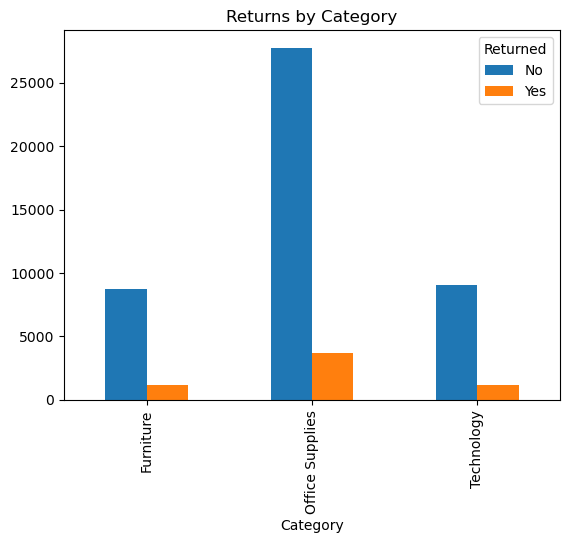

In [19]:
df.groupby('Category')['Returned'].value_counts().unstack().plot(kind='bar')
plt.title("Returns by Category")
plt.show()

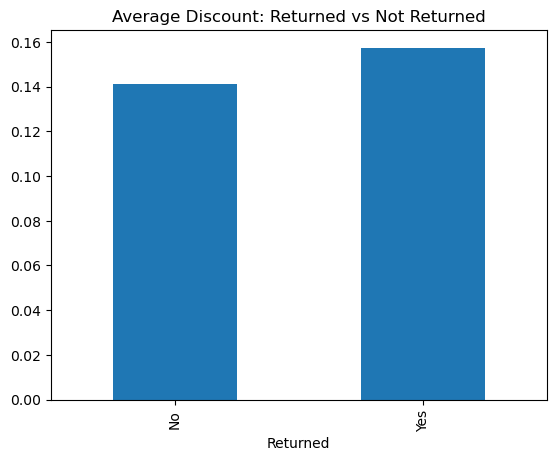

In [20]:
df.groupby('Returned')['Discount'].mean().plot(kind='bar')
plt.title("Average Discount: Returned vs Not Returned")
plt.show()

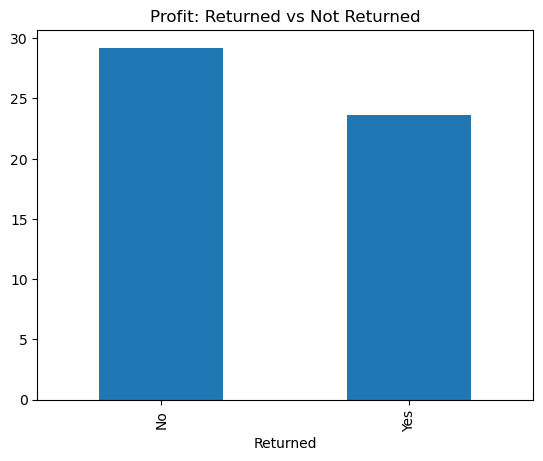

In [21]:
df.groupby('Returned')['Profit'].mean().plot(kind='bar')
plt.title("Profit: Returned vs Not Returned")
plt.show()

In [22]:
df.to_csv("final_data.csv", index=False)

In [24]:
df.to_csv(r"C:\Users\Chinmoyee Bhuyan\OneDrive\Desktop\final_data.csv", index=False)

**Insights**
1. Office supplies shows the highest number of returns.
2. Higher discounts are related to increased returns.
3. Returned products generate lower profit.
